In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from chemevo import evolution as evo

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]
linestyles = ['-', '--', ':', '-.']

In [28]:
t_array = np.linspace(0.0001,12,int(1e3))
tau_sfh = 6 #Gyrs
m_g_array_exp = 1 * np.exp(-t_array/tau_sfh)
m_g_array_const = np.ones(len(t_array))

In [29]:
def get_R_Ia(fcc):
    R_Ia = fcc**(-1) - 1
    return R_Ia

[9.         4.         2.33333333 1.5        1.         0.66666667
 0.42857143 0.25       0.11111111 0.        ]


Text(0, 0.5, '$R_{Ia}^{X}$')

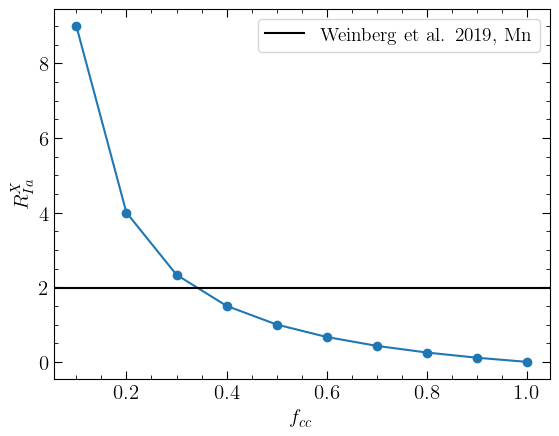

In [30]:
fccs = np.linspace(0.1,1,10)
R_Ias = get_R_Ia(fccs)
print(R_Ias)

plt.plot(fccs, R_Ias, marker='o')
plt.axhline(1.97, label = 'Weinberg et al. 2019, Mn', color = 'black')
plt.legend()
plt.xlabel(r'$f_{cc}$')
plt.ylabel(r'$R_{Ia}^{X}$')

In [31]:
R_Ias = [8, 2, 1.5, 1, 0.5, 0]

# 1) $R_{Ia}^{Mn}$

## 1.1) Constant SFR

In [32]:
gals_c = []

#gals_c are for constant SFR
for R_Ia in R_Ias:
    gals_c.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, R_Ia_Mn=R_Ia))

#gals_e are for exponential SFR
gals_e = []

for R_Ia in R_Ias:
    gals_e.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp, R_Ia_Mn=R_Ia))

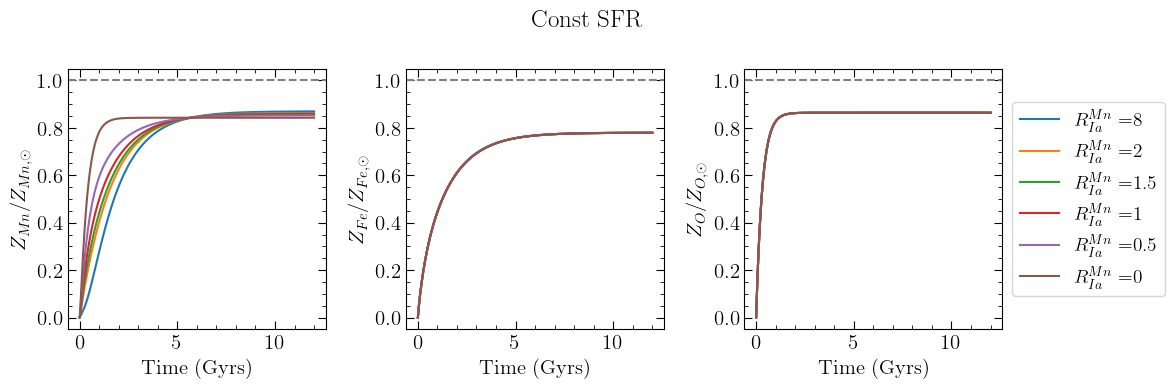

In [33]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
for i in range(len(R_Ias)):
    plt.plot(t_array, gals_c[i].compute_z_Mn()/gals_c[i].SolarMn, label = r"$R_{Ia}^{Mn} = $" + f"{R_Ias[i]}")
plt.xlabel('Time (Gyrs)')
plt.ylabel(r'$Z_{Mn}/Z_{Mn, \odot}$')
plt.axhline(1, color = 'gray', linestyle='--')


plt.subplot(1,3,2)
for i in range(len(R_Ias)):
    plt.plot(t_array, gals_c[i].compute_z_Fe()/gals_c[i].SolarFe, label = r"$R_{Ia}^{Mn} = $" + f"{R_Ias[i]}")
plt.axhline(1, color = 'gray', linestyle='--')
plt.xlabel('Time (Gyrs)')
plt.ylabel(r'$Z_{Fe}/Z_{Fe, \odot}$')

plt.subplot(1,3,3)
for i in range(len(R_Ias)):
    plt.plot(t_array, gals_c[i].compute_z_O()/gals_c[i].SolarO, label = r"$R_{Ia}^{Mn} = $" + f"{R_Ias[i]}")
plt.axhline(1, color = 'gray', linestyle='--')
plt.xlabel('Time (Gyrs)')
plt.ylabel(r'$Z_{O}/Z_{O, \odot}$')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.suptitle('Const SFR')
plt.tight_layout()

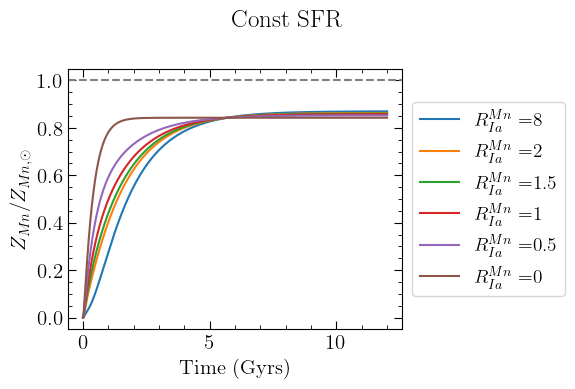

In [34]:
plt.figure(figsize=(6,4))

for i in range(len(R_Ias)):
    plt.plot(t_array, gals_c[i].compute_z_Mn()/gals_c[i].SolarMn, label = r"$R_{Ia}^{Mn} = $" + f"{R_Ias[i]}")
plt.xlabel('Time (Gyrs)')
plt.ylabel(r'$Z_{Mn}/Z_{Mn, \odot}$')
plt.axhline(1, color = 'gray', linestyle='--')


plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.suptitle('Const SFR')
plt.tight_layout()

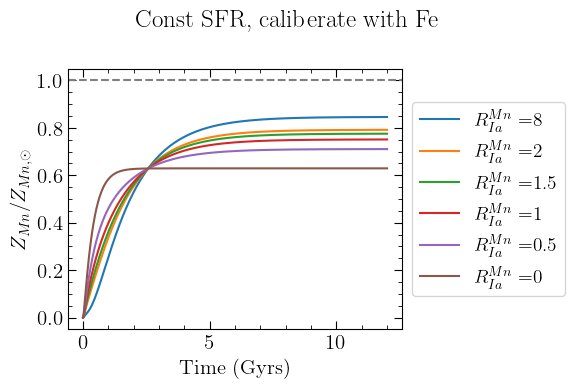

In [35]:
SolarMn = gals_c[0].SolarMn
plt.figure(figsize=(6,4))

for i in range(len(R_Ias)):
    plt.plot(t_array, gals_c[i].compute_z_X_with_Fe(R_Ia_X=R_Ias[i], alpha_cc_X=0.17, alpha_Ia_X=0.30, SolarX=SolarMn)/gals_c[i].SolarMn, label = r"$R_{Ia}^{Mn} = $" + f"{R_Ias[i]}")
plt.xlabel('Time (Gyrs)')
plt.ylabel(r'$Z_{Mn}/Z_{Mn, \odot}$')
plt.axhline(1, color = 'gray', linestyle='--')


plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.suptitle('Const SFR, caliberate with Fe')
plt.tight_layout()

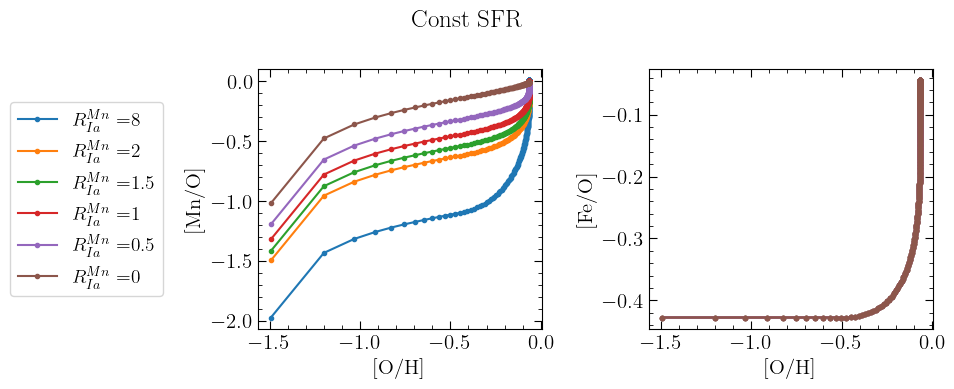

In [36]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
for i in range(len(R_Ias)):
    plt.plot(gals_c[i].O_H[1:], gals_c[i].Mn_O[1:], label = r"$R_{Ia}^{Mn} = $" + f"{R_Ias[i]}",
             marker='o', markersize = 3)
plt.xlabel('[O/H]')
plt.ylabel('[Mn/O]')
plt.legend(loc='center right', bbox_to_anchor=(-0.3, 0.5))

plt.subplot(1,2,2)
for i in range(len(R_Ias)):
    plt.plot(gals_c[i].O_H[1:], gals_c[i].Fe_O[1:], label = r"$R_{Ia}^{Mn} = $" + f"{R_Ias[i]}", 
             marker='o', markersize = 3)
plt.xlabel('[O/H]')
plt.ylabel('[Fe/O]')

plt.suptitle('Const SFR')
plt.tight_layout()

## 1.2) Exp SFR

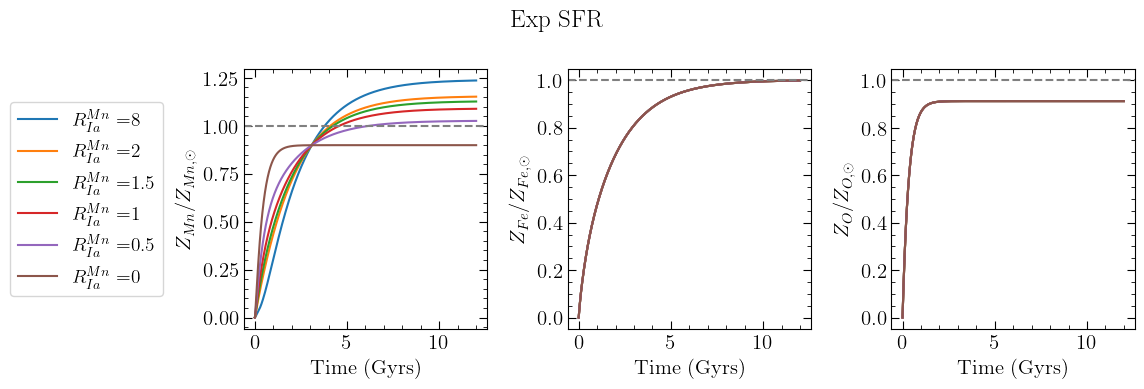

In [37]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
for i in range(len(R_Ias)):
    plt.plot(t_array, gals_e[i].compute_z_Mn()/gals_e[i].SolarMn, label = r"$R_{Ia}^{Mn} = $" + f"{R_Ias[i]}")
plt.xlabel('Time (Gyrs)')
plt.ylabel(r'$Z_{Mn}/Z_{Mn, \odot}$')
plt.axhline(1, color = 'gray', linestyle='--')
plt.legend(loc='center left', bbox_to_anchor=(-1, 0.5))

plt.subplot(1,3,2)
for i in range(len(R_Ias)):
    plt.plot(t_array, gals_e[i].compute_z_Fe()/gals_e[i].SolarFe, label = r"$R_{Ia}^{Mn} = $" + f"{R_Ias[i]}")
plt.axhline(1, color = 'gray', linestyle='--')
plt.xlabel('Time (Gyrs)')
plt.ylabel(r'$Z_{Fe}/Z_{Fe, \odot}$')

plt.subplot(1,3,3)
for i in range(len(R_Ias)):
    plt.plot(t_array, gals_e[i].compute_z_O()/gals_e[i].SolarO, label = r"$R_{Ia}^{Mn} = $" + f"{R_Ias[i]}")
plt.axhline(1, color = 'gray', linestyle='--')
plt.xlabel('Time (Gyrs)')
plt.ylabel(r'$Z_{O}/Z_{O, \odot}$')

plt.suptitle('Exp SFR')
plt.tight_layout()

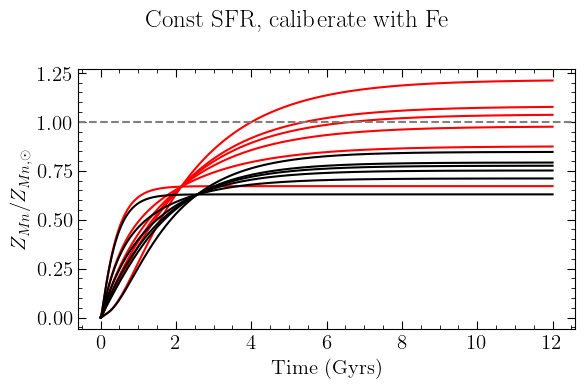

In [42]:
SolarMn = gals_e[0].SolarMn
plt.figure(figsize=(6,4))

for i in range(len(R_Ias)):
    plt.plot(t_array, gals_e[i].compute_z_X_with_Fe(R_Ia_X=R_Ias[i], alpha_cc_X=0.17,
                                                    alpha_Ia_X=0.30, SolarX=SolarMn)/gals_e[i].SolarMn,
                                                    label = r"$R_{Ia}^{Mn} = $" + f"{R_Ias[i]}", color = 'red')

for i in range(len(R_Ias)):
    plt.plot(t_array, gals_c[i].compute_z_X_with_Fe(R_Ia_X=R_Ias[i], alpha_cc_X=0.17,
                                                    alpha_Ia_X=0.30, SolarX=SolarMn)/gals_c[i].SolarMn,
                                                    label = r"$R_{Ia}^{Mn} = $" + f"{R_Ias[i]}", color = 'black')

plt.xlabel('Time (Gyrs)')
plt.ylabel(r'$Z_{Mn}/Z_{Mn, \odot}$')
plt.axhline(1, color = 'gray', linestyle='--')


#plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.suptitle('Const SFR, caliberate with Fe')
plt.tight_layout()

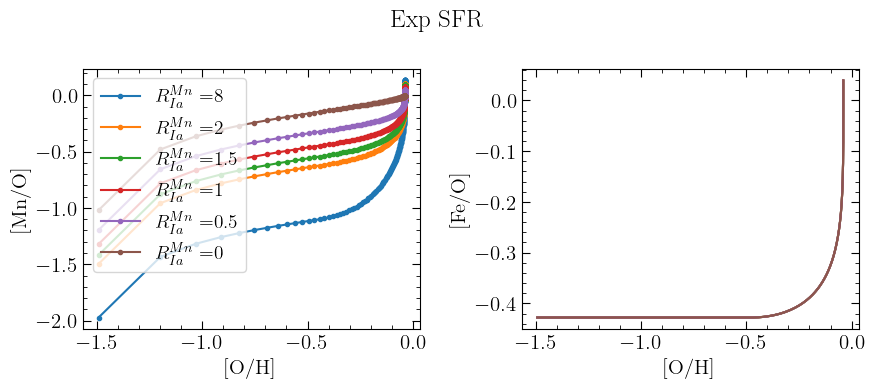

In [38]:
plt.figure(figsize=(9,4))
plt.subplot(1,2,1)
for i in range(len(R_Ias)):
    plt.plot(gals_e[i].O_H[1:], gals_e[i].Mn_O[1:], label = r"$R_{Ia}^{Mn} = $" + f"{R_Ias[i]}",
             marker='o', markersize = 3)
plt.xlabel('[O/H]')
plt.ylabel('[Mn/O]')
plt.legend()

plt.subplot(1,2,2)
for i in range(len(R_Ias)):
    plt.plot(gals_e[i].O_H[1:], gals_e[i].Fe_O[1:], label = r"$R_{Ia}^{Mn} = $" + f"{R_Ias[i]}")
plt.xlabel('[O/H]')
plt.ylabel('[Fe/O]')

plt.suptitle('Exp SFR')
plt.tight_layout()

In [ ]:
def ratio_to_sun(star, sun):
        ratio = np.log10(star/sun + 1e-6)
        #ratio[np.where(ratio <= -10)] = 0
        return ratio
Mn_H_with_Fes = []
for i in range(len(R_Ias)):
        Mn_H_with_Fe = ratio_to_sun(gals_c[i].compute_z_X_with_Fe(R_Ia_X=R_Ias[i], alpha_cc_X=0.17,
                                                    alpha_Ia_X=0.30, SolarX=SolarMn), sun=SolarMn)
        Mn_H_with_Fes.append(Mn_H_with_Fe)

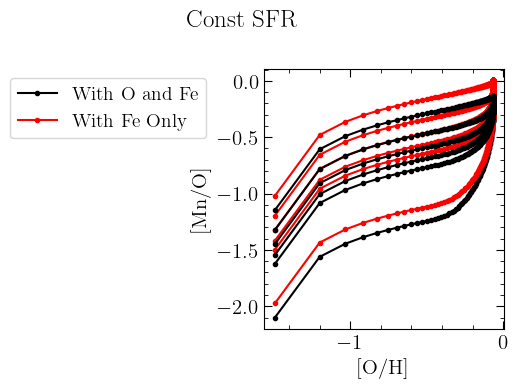

In [62]:
plt.figure(figsize=(6,4))
for i in range(len(R_Ias)):
    Mn_H_with_Fe = Mn_H_with_Fes[i]
    if i == 0:
        label_1 = 'With O and Fe'
        label_2 = 'With Fe Only'
        plt.plot(gals_c[i].O_H[1:], Mn_H_with_Fe[1:] - gals_c[i].O_H[1:],
             marker='o', markersize = 3, color = 'black', label = label_1)
        plt.plot(gals_c[i].O_H[1:], gals_c[i].Mn_O[1:],
             marker='o', markersize = 3, color = 'red', label = label_2)
    else:
        plt.plot(gals_c[i].O_H[1:], Mn_H_with_Fe[1:] - gals_c[i].O_H[1:],
                marker='o', markersize = 3, color = 'black')
        plt.plot(gals_c[i].O_H[1:], gals_c[i].Mn_O[1:],
                marker='o', markersize = 3, color = 'red')
    
plt.xlabel('[O/H]')
plt.ylabel('[Mn/O]')
plt.legend(bbox_to_anchor=[-0.2, 1])

plt.suptitle('Const SFR')
plt.tight_layout()